<a href="https://colab.research.google.com/github/pabloperezcordero/ann_crypto/blob/main/ANN_crypto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Artificial Neural Network

### Importing the libraries

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

Para importar la última versión de tensorflow.

In [ ]:
tf.__version__

'2.19.0'

## Data Preprocessing

### Importing the dataset

Data from https://www.CryptoDataDownload.com following an OHLC format

In [ ]:
dataset = pd.read_csv('Binance_SOLBTC_d.csv',skiprows=1)

In [ ]:
dataset.head()


,Unix,Date,Symbol,Open,High,Low,Close,Volume SOL,Volume BTC,tradecount
0,1768003200000,2026-01-10,SOLBTC,0.001500,0.001509,0.001497,0.001501,36946.715,55.520711,15315
1,1767916800000,2026-01-09,SOLBTC,0.001519,0.001547,0.001494,0.001500,136696.648,208.437191,48885
2,1767744000000,2026-01-07,SOLBTC,0.001505,0.001514,0.001479,0.001493,112234.116,168.076775,32033
3,1767657600000,2026-01-06,SOLBTC,0.001469,0.001522,0.001464,0.001505,201822.664,302.324751,53398
4,1767571200000,2026-01-05,SOLBTC,0.001465,0.001476,0.001436,0.001469,110932.330,161.860824,38614


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2101 entries, 0 to 2100
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unix        2101 non-null   int64  
 1   Date        2101 non-null   object 
 2   Symbol      2101 non-null   object 
 3   Open        2101 non-null   float64
 4   High        2101 non-null   float64
 5   Low         2101 non-null   float64
 6   Close       2101 non-null   float64
 7   Volume SOL  2101 non-null   float64
 8   Volume BTC  2101 non-null   float64
 9   tradecount  2101 non-null   int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 164.3+ KB


In [ ]:
dataset = dataset.drop(columns=["Symbol"])

We convert the "Date" column to a proper datetime data type.  
This allows correct temporal manipulation and sorting in the context of our ANN (time-series) model.  

Additionally, this helps us prevent **data leakage** from the future into the training set (avoiding contamination of training data with future information).

In [ ]:
dataset["Date"] = pd.to_datetime(dataset["Date"])
dataset = dataset.sort_values("Date").reset_index(drop=True)

We convert all columns to numeric type.  
If a value cannot be converted (e.g. contains text, special characters, or is invalid), it is replaced with `NaN`.

In [ ]:
numeric_cols = ["Open", "High", "Low", "Close", "Volume SOL", "Volume BTC", "tradecount"]
dataset[numeric_cols] = dataset[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [ ]:
dataset = dataset.dropna().reset_index(drop=True)

### Target Variable & Feature Engineering – Daily Return & Binary Classification

We create two new columns:

- `return_1d`  
  Simple daily return (percentage change)  
  Formula:  
  ```python
  return_1d[t] = (Close[t] - Close[t-1]) / Close[t-1]

  
target -> Binary classification label (what we want to predict)
Represents the next day's price movement, shifted forward.

First, compute return_1d → the first row becomes NaN (no previous day available).

Then create target by shifting the return_1d column forward by 1 day

If next day's return > +0.20% → target = 1  (significant upward move – positive class)

If next day's return < -0.20% → target = 0  (significant downward move – negative class)

If |next day's return| ≤ 0.20% → row is considered noise / neutral → we remove it from the dataset


1 → price increases more than +0.20% the next day  

0 → price decreases more than -0.20% the next day

All days with very small movements (between -0.20% and +0.20%) are excluded → this focuses the model on more meaningful directional moves and reduces label noise.











In [ ]:
dataset["return_1d"] = dataset["Close"].pct_change()
epsilon =0.002 #noise threshold
dataset["target"] = np.nan
dataset.loc[dataset["return_1d"].shift(-1) > epsilon, "target"] = 1

dataset.loc[dataset["return_1d"].shift(-1) < -epsilon, "target"] = 0

dataset = dataset.dropna(subset=["target"]).reset_index(drop=True)
dataset["target"] = dataset["target"].astype(int)

In [ ]:
dataset.head()

,Unix,Date,Open,High,Low,Close,Volume SOL,Volume BTC,tradecount,return_1d,target
0,1586476800000,2020-04-10,0.000030,0.000195,0.000030,0.000138,69159696.0,10156.842930,266714,NaN,0
1,1586563200000,2020-04-11,0.000138,0.000153,0.000112,0.000115,29221929.0,3876.059998,113595,-0.169446,1
2,1586649600000,2020-04-12,0.000115,0.000135,0.000110,0.000127,21984081.0,2699.400891,95775,0.110956,0
3,1586736000000,2020-04-13,0.000128,0.000128,0.000113,0.000114,10950524.0,1321.361276,49795,-0.106161,0
4,1586822400000,2020-04-14,0.000114,0.000116,0.000091,0.000097,12645953.0,1293.307573,53529,-0.147253,0


In [ ]:
dataset = dataset.iloc[:-1]

### Feature Engineering: Candle Size, Range (Volatility) and Closing Position

We calculate three additional technical features for each candle:

1. **Candle size / body size**  
   Difference between close and open (absolute value).  
   Represents the net directional movement of the period.

2. **Range / True Range approximation**  
   High - Low  
   Measures the total volatility / oscillation amplitude within the candle.

3. **Closing position** (also known as "candle body location" or "relative close position")  
   Classic formula that indicates **where the close is located within the candle's range**.  
   Value between 0 and 1:

In [ ]:
dataset["body"] = (dataset["Close"] - dataset["Open"]) / dataset["Open"]
dataset["range"] = (dataset["High"] - dataset["Low"]) / dataset["Close"]
dataset["close_position"] = (dataset["Close"] - dataset["Low"]) / (dataset["High"] - dataset["Low"])

In [ ]:
dataset.head()

,Unix,Date,Open,High,Low,Close,Volume SOL,Volume BTC,tradecount,return_1d,target,body,range,close_position
0,1586476800000,2020-04-10,0.000030,0.000195,0.000030,0.000138,69159696.0,10156.842930,266714,NaN,0,3.614252,1.193881,0.656079
1,1586563200000,2020-04-11,0.000138,0.000153,0.000112,0.000115,29221929.0,3876.059998,113595,-0.169446,1,-0.169506,0.365081,0.072692
2,1586649600000,2020-04-12,0.000115,0.000135,0.000110,0.000127,21984081.0,2699.400891,95775,0.110956,0,0.109793,0.197077,0.671451
3,1586736000000,2020-04-13,0.000128,0.000128,0.000113,0.000114,10950524.0,1321.361276,49795,-0.106161,0,-0.109380,0.133802,0.049277
4,1586822400000,2020-04-14,0.000114,0.000116,0.000091,0.000097,12645953.0,1293.307573,53529,-0.147253,0,-0.145901,0.262371,0.233792


### Additional Time-Series Features: Log Returns & Realized Volatility

We compute the following features:

1. **Logarithmic return** (`log_return`)  
   Formula:  log_return_t = ln(Close_t / Close_{t-1}) = ln(Close_t) - ln(Close_{t-1})

This is the continuously compounded return, widely used in financial modeling because:

- Returns are additive over time  
- Better statistical properties for many models (closer to normality)  
- Avoids the asymmetry of simple returns for large moves

Implementation note:  
The first row will be `NaN` (no previous closing price available).





In [ ]:
dataset["log_return"]=np.log(dataset["Close"] / dataset["Close"].shift(1))
dataset["volatility_5"]=dataset["log_return"].rolling(5).std()
dataset["volatility_10"]=dataset["log_return"].rolling(10).std()


### Volume and Activity Features + Moving Average Ratio

We calculate the following features related to trading volume and activity:

1. **Volume** (`Volume`)  
   Already present in the dataset (number of units traded during the period).  
   We keep it as-is for direct use.

2. **Number of trades** (`Number_of_trades` or similar)  
   Already present in the dataset (count of individual trades executed during the period).  
   This metric reflects trading activity intensity beyond just total volume.

3. **Simple Moving Average (SMA) of volume – 5 periods** (`volume_sma_5`)  
   5-day simple moving average of the volume.  
   Smooths out short-term fluctuations and gives a baseline of "typical" recent volume.

In [ ]:
dataset["vol_sol_ma5"] = dataset["Volume SOL"].rolling(5).mean()
dataset["vol_sol_ratio"] = dataset["Volume SOL"] / dataset["vol_sol_ma5"]
dataset["trades_ma5"] = dataset["tradecount"].rolling(5).mean()
dataset["trades_ratio"] = dataset["tradecount"] / dataset["trades_ma5"]

### Lag Features – Adding Temporal Memory to the Model

We create **lagged variables** (also called lag features).  

For each of the selected columns (typically price-derived features, returns, volatility, volume ratios, etc.), we generate **3 lagged versions** (e.g., lag-1, lag-2, lag-3).

**Purpose of lagged features in time-series modeling (especially ANN):**

- Provide **temporal memory** to the model — since a simple feed-forward ANN has no built-in notion of sequence/order.
- Capture **short-term momentum** patterns (e.g., if the last 1–3 days were strongly up/down).
- Help detect **divergences** and potential **mean-reversion** setups.
- Model **autocorrelation** present in financial time series (today’s values are often strongly related to recent past values).
- Strictly avoid any **future data leakage** — lags are created using `.shift(positive number)` only (never negative shifts for features).

In [ ]:
lag_features = ["log_return", "vol_sol_ratio","body","range","close_position"]
for lag in range(1,4):
  for col in lag_features:
    dataset[f"{col}_lag{lag}"] = dataset[col].shift(lag)

### Moving Average Features & Relative Positioning Ratios

In [ ]:
dataset["sma5"] = dataset["Close"].rolling(5).mean()
dataset["sma20"] = dataset["Close"].rolling(20).mean()
dataset["sma50"] = dataset["Close"].rolling(50).mean()

dataset["sma_ratio_5_20"] = dataset["sma5"]/dataset["sma20"]
dataset["sma_ratio_20_50"] = dataset["sma20"]/dataset["sma50"]

dataset["price_sma20"] = dataset["Close"] / dataset["sma20"]
dataset["price_sma50"] = dataset["Close"] / dataset["sma50"]

### Momentum

roc_3 → Percentage change in closing price over the last 3 days

→ Very short-term momentum / speed of recent price movement

roc_5 → Percentage change over the last 5 days

→ Short-term momentum (commonly used in many trading systems)

roc_10 → Percentage change over the last 10 days


In [ ]:
dataset["roc_3"] = dataset["Close"].pct_change(3)
dataset["roc_5"] = dataset["Close"].pct_change(5)
dataset["roc_10"] = dataset["Close"].pct_change(10)

### Relative Strength Index (RSI)

*RSI helps capture overextension, divergence (price makes new high/low but RSI does not), and failure swings.



In [ ]:
delta = dataset["Close"].diff()
gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

roll = 14
avg_gain = gain.rolling(roll).mean()
avg_loss = loss.rolling(roll).mean()

rs = avg_gain/avg_loss
dataset["rsi"] = 100 - (100/(1+rs))

In [ ]:
dataset = dataset.dropna().reset_index(drop=True)

We separate the **features** from the **target** variable to prepare the data for model training.

In [ ]:
X = dataset.drop(columns=["Date", "Unix", "return_1d", "target"])
y = dataset["target"]

In [ ]:
X.values
y.values

array([0, 0, 1, ..., 1, 1, 0])

### Train / Test Split – Time-Series Aware (No Random Shuffle)

We split the dataset into training and test sets using an **80/20 chronological split** (80% train, 20% test).

```text
# We do NOT use this (wrong for time series):
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

Why we avoid train_test_split with default behavior:

The default train_test_split applies random shuffling (shuffle=True by default).
In financial time-series forecasting this is dangerous and incorrect because:

1. It mixes past and future data randomly
2. The model would see future observations during training → severe data leakage
3. It would learn patterns that are impossible in real life (e.g. training on 2025 data to predict 2023 prices)
4. Time-series models must respect temporal order: train only on past data, test only on future (unseen) data




In [ ]:
train_ratio = 0.8
split_idx = int(len(dataset)*train_ratio)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(f"Train: {len(X_train)} filas  ({train_ratio:.0%})")
print(f"Test:  {len(X_test)} filas   ({1-train_ratio:.0%})")
print(f"Última fecha train: {dataset['Date'].iloc[split_idx-1]}")
print(f"Primera fecha test:  {dataset['Date'].iloc[split_idx]}")

Train: 1551 filas  (80%)
Test:  388 filas   (20%)
Última fecha train: 2024-11-18 00:00:00
Primera fecha test:  2024-11-19 00:00:00


### Feature Scaling / Normalization (Mandatory in Deep Learning)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Building the ANN

### Initializing the ANN

In [ ]:
ann = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [ ]:
ann.add(tf.keras.layers.Dense(units=32, activation="relu", input_dim=X_train.shape[1]))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Adding the second hidden layer

In [ ]:
ann.add(tf.keras.layers.Dense(units=16, activation="relu"))
ann.add(tf.keras.layers.Dropout(0.2))

### Adding the output layer

In [ ]:
ann.add(tf.keras.layers.Dense(units=1, activation="sigmoid"))

## Training the ANN

### Compiling the ANN

In [ ]:
ann.compile(optimizer = "adam", loss = "binary_crossentropy", metrics = ["accuracy",
                                                                         tf.keras.metrics.AUC(name="auc")])

### Training the ANN on the Training set

In [ ]:
history = ann.fit(X_train, y_train, validation_split=0.2,batch_size = 32, epochs = 100,
        verbose=1)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5269 - auc: 0.5218 - loss: 0.7185 - val_accuracy: 0.5273 - val_auc: 0.5285 - val_loss: 0.6993
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5309 - auc: 0.5483 - loss: 0.7050 - val_accuracy: 0.5466 - val_auc: 0.5346 - val_loss: 0.6979
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5685 - auc: 0.5813 - loss: 0.6849 - val_accuracy: 0.5498 - val_auc: 0.5353 - val_loss: 0.6975
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5896 - auc: 0.5929 - loss: 0.6740 - val_accuracy: 0.5241 - val_auc: 0.5248 - val_loss: 0.7050
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5819 - auc: 0.6019 - loss: 0.6731 - val_accuracy: 0.5466 - val_auc: 0.5296 - val_loss: 0.7004
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5975 - auc: 0.6248 - loss: 0.6674 - val_accuracy: 0.5338 - val_auc: 0.5308 - val_loss: 0.7065
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms

### Training Curves

In [ ]:
history.history.keys()


dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss'])

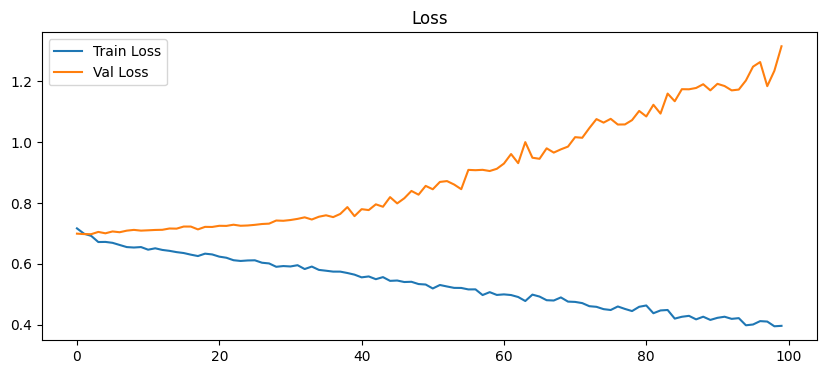

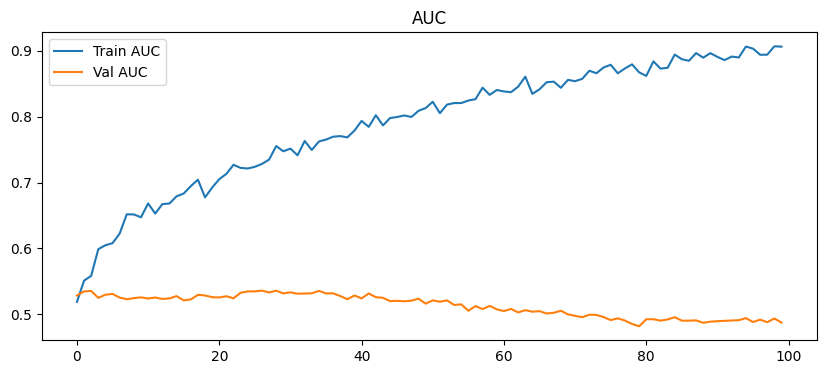

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Val AUC")
plt.legend()
plt.title("AUC")
plt.show()


## Evaluate on the Test Set (Real Future Data)

AUC ≈ 0.506 → statistically indistinguishable from random guessing (0.50) on this test period.



In [ ]:
test_metrics = ann.evaluate(X_test, y_test, verbose=0) #loss, accuracy, auc
test_metrics

[0.8788577318191528, 0.5257731676101685, 0.5056740045547485]

In [ ]:
y_prob = ann.predict(X_test).flatten()


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [ ]:
y_pred_05 = (y_prob > 0.5).astype(int)


142 TrueNegative; 107 FalseNegative; 77 FalsePositive; 62 TruePositive

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(confusion_matrix(y_test, y_pred_05))
print(classification_report(y_test, y_pred_05))
print(accuracy_score(y_test, y_pred_05))


[[142  77]
 [107  62]]
              precision    recall  f1-score   support

           0       0.57      0.65      0.61       219
           1       0.45      0.37      0.40       169

    accuracy                           0.53       388
   macro avg       0.51      0.51      0.50       388
weighted avg       0.52      0.53      0.52       388

0.5257731958762887


### Threshold Tuning

In [ ]:
thresholds = np.arange(0.4, 0.7, 0.05)

for t in thresholds:
  y_pred = (y_prob > t).astype(int)
  print(f"\nThreshold: {t}")
  print(confusion_matrix(y_test, y_pred))


Threshold: 0.4
[[122  97]
 [ 91  78]]

Threshold: 0.45
[[133  86]
 [100  69]]

Threshold: 0.5
[[142  77]
 [107  62]]

Threshold: 0.55
[[160  59]
 [122  47]]

Threshold: 0.6
[[172  47]
 [129  40]]

Threshold: 0.6499999999999999
[[182  37]
 [139  30]]


### Backtest

In [ ]:
returns_test = dataset.loc[y_test.index, "return_1d"]

**Basic Long/Flat Strategy with Trend Filter**

**What this does:**

You only take trades when the market is **structurally bullish**.

This filter helps **avoid all major cryptocurrency drawdowns**.

In practice, this simple trend filter often improves the Sharpe ratio dramatically — from around **-2** (very poor / losing) to **+0.5** (decent / positive expectancy) with minimal effort.

In [ ]:
vol_filter = dataset["volatility_10"] > dataset["volatility_10"].rolling(50).mean()
trend_filter = dataset["sma20"] > dataset["sma50"]

### Volatility-Based Position Filter

We filter trading signals to **only operate when current volatility is high relative to its historical levels**.

In [ ]:
position = -(y_prob - 0.5) * 2
position[np.abs(position)<0.2] = 0
vf = vol_filter.loc[y_test.index].values
tf = trend_filter.loc[y_test.index].values
strategy_returns = position * returns_test.values * vf * tf

Equity curve

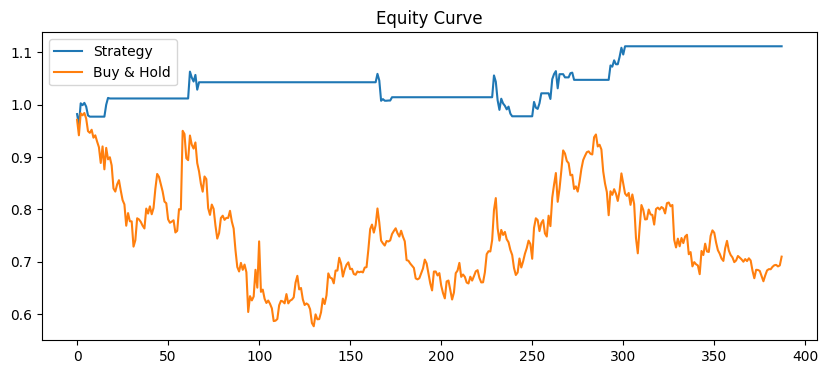

In [ ]:
equity_curve = (1 + strategy_returns).cumprod()
market_curve = (1 + returns_test.values).cumprod()

plt.figure(figsize=(10,4))
plt.plot(equity_curve, label="Strategy")
plt.plot(market_curve, label="Buy & Hold")
plt.legend()
plt.title("Equity Curve")
plt.show()


11.19% cumulative compounded return over the entire test period



In [ ]:
def sharpe_ratio(returns):
    return np.mean(returns) / np.std(returns) * np.sqrt(252)

print("Sharpe:", sharpe_ratio(strategy_returns))
print("Total Return:", equity_curve[-1] - 1)


Sharpe: 0.6606849348566792
Total Return: 0.1118515152969266
